<a href="https://colab.research.google.com/github/apurva2698/cv/blob/main/Tesco_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded. Shape: (541910, 8)
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  
3 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
4 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  

Cleaned data sample:
  invoice stockcode                          description  quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053   

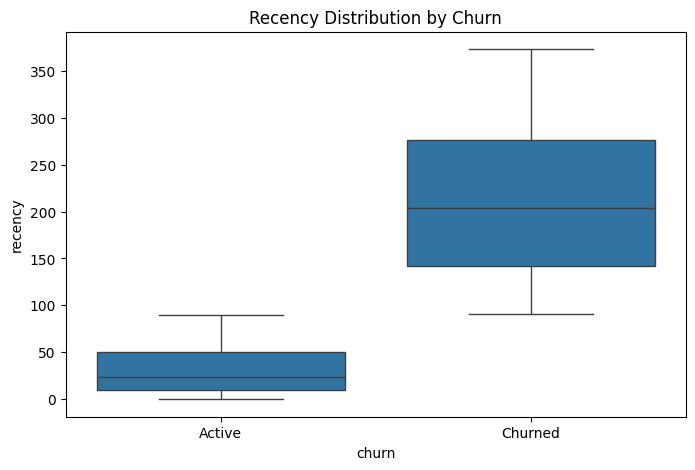

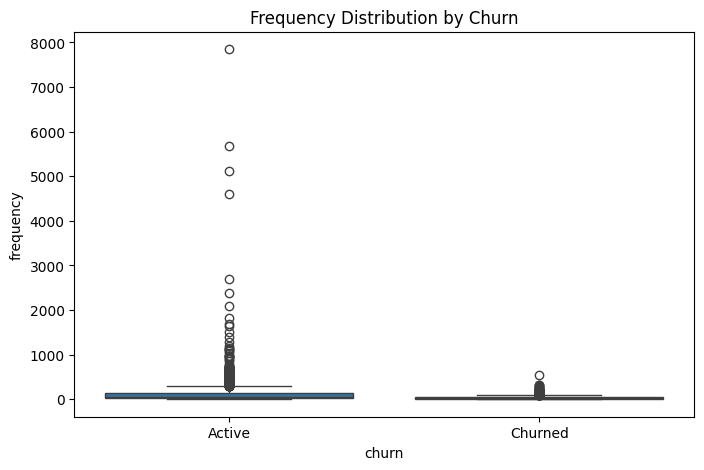

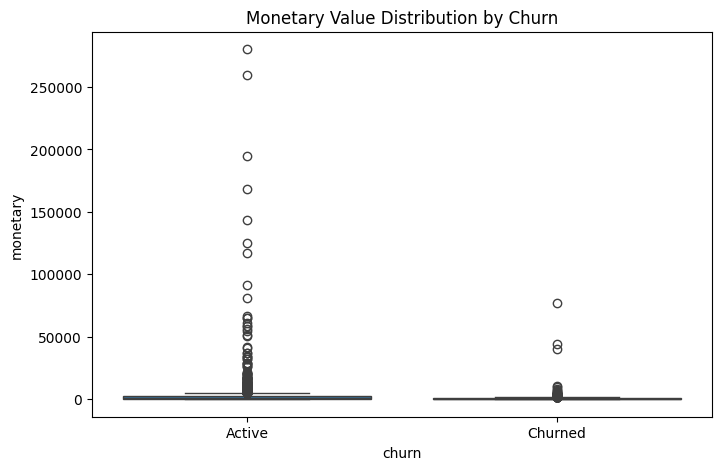

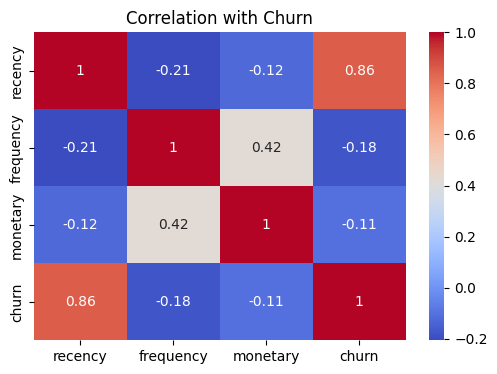


=== Logistic Regression Evaluation ===
Confusion Matrix:
 [[579   0]
 [  9 280]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       579
           1       1.00      0.97      0.98       289

    accuracy                           0.99       868
   macro avg       0.99      0.98      0.99       868
weighted avg       0.99      0.99      0.99       868

ROC AUC Score: 1.0

Feature coefficients:
recency: 11.3268
frequency: -0.0501
monetary: -0.2131

=== Random Forest Evaluation ===
ROC AUC Score: 1.0

Random Forest Feature Importances:
recency: 0.8755
frequency: 0.0638
monetary: 0.0607

Key Insights:
1. Recency is the strongest driver of churn: customers inactive for long periods are at highest risk.
2. Lower frequency and lower monetary value also increase churn probability.
3. Using this model, Tesco can proactively target high-risk customers with retention campaigns.
4. Logistic Regression gives interpretab

In [2]:
# ==============================
# TESCO-LIKE RETAIL CUSTOMER CHURN ANALYSIS
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# ------------------------------
# 1. Load Dataset
# ------------------------------

# Upload file if using Colab:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_excel("online_retail_II.xlsx", sheet_name='Year 2010-2011')
print("Dataset loaded. Shape:", df.shape)
print(df.head())

# ------------------------------
# 2. Data Cleaning
# ------------------------------

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Remove missing customer_id and negative quantities
df = df[df['customer_id'].notna()]
df = df[df['quantity'] > 0]

# Create total spend
df['total_spend'] = df['quantity'] * df['price']

# Convert invoice date
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

print("\nCleaned data sample:")
print(df.head())

# ------------------------------
# 3. RFM Calculation
# ------------------------------

customer_df = df.groupby('customer_id').agg({
    'invoicedate': 'max',   # last purchase
    'invoice': 'count',     # frequency
    'total_spend': 'sum'    # monetary
})

customer_df.columns = ['last_purchase', 'frequency', 'monetary']

# Recency in days
today = df['invoicedate'].max()
customer_df['recency'] = (today - customer_df['last_purchase']).dt.days
customer_df = customer_df.reset_index()

print("\nRFM table sample:")
print(customer_df.head())

# ------------------------------
# 4. Define Churn
# ------------------------------

# Rule: inactive > 90 days = churned
customer_df['churn'] = customer_df['recency'].apply(lambda x: 1 if x > 90 else 0)

# Churn distribution
print("\nChurn distribution:")
print(customer_df['churn'].value_counts())

# ------------------------------
# 5. Exploratory Analysis: RFM vs Churn
# ------------------------------

# Recency
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='recency', data=customer_df)
plt.title('Recency Distribution by Churn')
plt.xticks([0,1], ['Active', 'Churned'])
plt.show()

# Frequency
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='frequency', data=customer_df)
plt.title('Frequency Distribution by Churn')
plt.xticks([0,1], ['Active', 'Churned'])
plt.show()

# Monetary
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='monetary', data=customer_df)
plt.title('Monetary Value Distribution by Churn')
plt.xticks([0,1], ['Active', 'Churned'])
plt.show()

# Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(customer_df[['recency','frequency','monetary','churn']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation with Churn')
plt.show()

# ------------------------------
# 6. Churn Prediction: Logistic Regression
# ------------------------------

X = customer_df[['recency','frequency','monetary']]
y = customer_df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression())
])

logreg_pipeline.fit(X_train, y_train)
y_pred = logreg_pipeline.predict(X_test)
y_proba = logreg_pipeline.predict_proba(X_test)[:,1]

print("\n=== Logistic Regression Evaluation ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

# Feature importance
features = X.columns
coefficients = logreg_pipeline.named_steps['lr'].coef_[0]
print("\nFeature coefficients:")
for f, c in zip(features, coefficients):
    print(f"{f}: {c:.4f}")

# ------------------------------
# 7. Churn Prediction: Random Forest
# ------------------------------

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

print("\n=== Random Forest Evaluation ===")
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_rf))

# Feature importance
importances = rf.feature_importances_
print("\nRandom Forest Feature Importances:")
for f, imp in zip(features, importances):
    print(f"{f}: {imp:.4f}")

# ------------------------------
# 8. Insights for Interview / Business
# ------------------------------

print("""
Key Insights:
1. Recency is the strongest driver of churn: customers inactive for long periods are at highest risk.
2. Lower frequency and lower monetary value also increase churn probability.
3. Using this model, Tesco can proactively target high-risk customers with retention campaigns.
4. Logistic Regression gives interpretable coefficients, while Random Forest provides slightly higher predictive power.
""")